In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

current_dir = os.getcwd()

project_root = os.path.abspath(os.path.join(current_dir, ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
from utils import *

In [25]:
data = np.load('../data/eigs_semi_torus_d4.npy')

In [26]:
data.shape

(7, 4, 20)

In [29]:
gt = np.mean(data[-1], axis=0)
num_eigs = len(gt)

res = data[:6]

diff = res - gt
err_max = np.max(diff, axis=-1)
err_l2 = np.sqrt(np.sum(diff ** 2, axis=-1) / num_eigs)

In [31]:
gt

array([0.14685386, 0.55014278, 1.13646097, 1.13783567, 1.37235911,
       1.6443793 , 1.91690595, 2.26882978, 2.49214815, 2.90841748,
       3.61802105, 3.80745522, 4.1121629 , 4.22409384, 4.26347309,
       4.88118372, 4.98004152, 4.98020797, 5.53401285, 5.57123365])

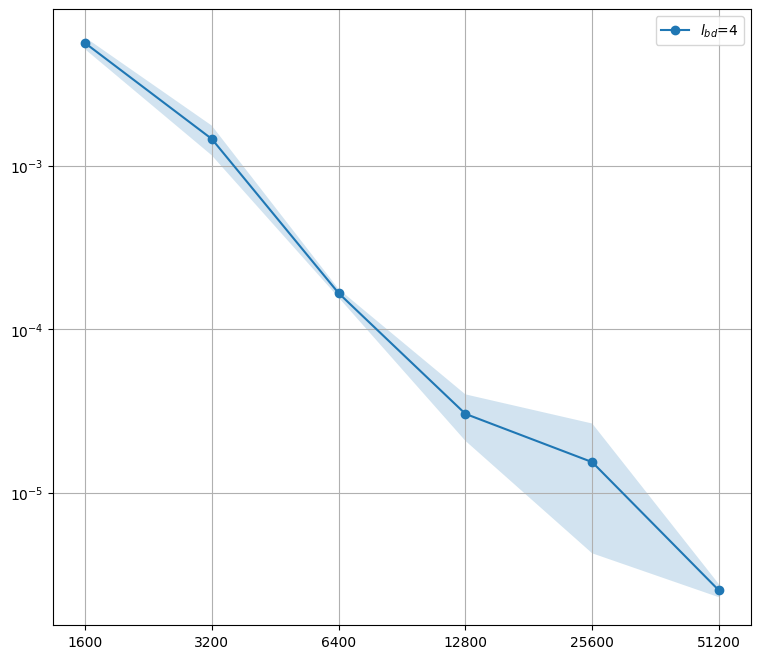

In [30]:
N_vals = [1600, 3200, 6400, 12800, 25600, 51200]

err = err_l2

mean = np.mean(err, axis=1)
std = np.std(err, axis=1)

d2 = {
    'mean': mean,
    'std': std,
    'plot_kwargs': {
        'label': r'$l_{bd}$=4'
    }
}

plot_convergence(N_vals, [d2], ref_list=[
    # ((1600, 2e-3), -1.0, ''),
    # ((1600, 1e-3), -1.5, ''),
    # ((1600, 8e-4), -2.0, ''),
])